# Stage 11 Homework — Evaluation & Risk Communication
In the lecture, we learned **gaussian-based vs bootstrap-based CIs**, **scenario sensitivity**, and **subgroup checks**.
Now, you will adapt those methods to your dataset and produce assumption-aware results.

In [ ]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install matplotlib

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

np.random.seed(111)

plt.rcParams["figure.figsize"] = (8, 5)

## Load Data (provided or synthetic fallback)

In [2]:
df = pd.read_csv(
    "../../project/data/raw/market_returns_spy_spmo.csv"
)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# Features use only information available before prediction
df["lag_excess"] = df["excess_return"].shift(1)

df["spy_vol_3"] = (
    df["spy_return"]
    .rolling(3)
    .std()
    .shift(1)
)

# Predict next month's momentum excess return
df["target_next_excess"] = df["excess_return"].shift(-1)

# Used only for subgroup diagnostics
df["market_regime"] = np.where(
    df["spy_return"] >= 0,
    "Up Market",
    "Down Market"
)

model_df = df[
    [
        "date",
        "lag_excess",
        "spy_vol_3",
        "target_next_excess",
        "market_regime"
    ]
].dropna().reset_index(drop=True)

model_df.head()

,date,lag_excess,spy_vol_3,target_next_excess,market_regime
0,2017-04-30,-0.0199,0.019098,0.0045,Up Market
1,2017-05-31,0.0161,0.019965,0.0089,Up Market
2,2017-06-30,0.0045,0.006580,0.0026,Up Market
3,2017-07-31,0.0089,0.003855,0.0078,Up Market
4,2017-08-31,0.0026,0.007108,-0.0081,Up Market


## Helper Functions (complete or modify as needed)

In [3]:
def bootstrap_mae(y_true, y_pred, n_boot=1000, seed=111):
    """
    Bootstrap MAE and return its distribution
    and 95% percentile confidence interval.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rng = np.random.default_rng(seed)
    n = len(y_true)

    stats = []

    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)

        stats.append(
            mean_absolute_error(
                y_true[idx],
                y_pred[idx]
            )
        )

    stats = np.array(stats)

    lower = np.percentile(stats, 2.5)
    upper = np.percentile(stats, 97.5)

    return stats, lower, upper

## Baseline Fit & Residuals (Required)

In [4]:
cut = int(len(model_df) * 0.8)

train = model_df.iloc[:cut].copy()
test = model_df.iloc[cut:].copy()

features = [
    "lag_excess",
    "spy_vol_3"
]

X_train = train[features]
y_train = train["target_next_excess"]

X_test = test[features]
y_test = test["target_next_excess"]

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

baseline_mae = mean_absolute_error(y_test, y_pred)
baseline_r2 = r2_score(y_test, y_pred)

print(f"Train observations: {len(train)}")
print(f"Test observations: {len(test)}")
print(f"Baseline MAE: {baseline_mae:.4f}")
print(f"Baseline R²: {baseline_r2:.4f}")

Train observations: 83
Test observations: 21
Baseline MAE: 0.0166
Baseline R²: -0.1876


## Gaussian-based vs Bootstrap-based CI (Required)

In [5]:
# Bootstrap CI for MAE
boot_mae, boot_lower, boot_upper = bootstrap_mae(
    y_test.to_numpy(),
    y_pred,
    n_boot=1000,
    seed=111
)

# Gaussian approximation CI for MAE
abs_errors = np.abs(
    y_test.to_numpy() - y_pred
)

mean_error = abs_errors.mean()

se_error = (
    abs_errors.std(ddof=1)
    / np.sqrt(len(abs_errors))
)

gaussian_lower = mean_error - 1.96 * se_error
gaussian_upper = mean_error + 1.96 * se_error

print(f"Observed MAE: {baseline_mae:.4f}")

print(
    f"Gaussian 95% CI: "
    f"[{gaussian_lower:.4f}, {gaussian_upper:.4f}]"
)

print(
    f"Bootstrap 95% CI: "
    f"[{boot_lower:.4f}, {boot_upper:.4f}]"
)

Observed MAE: 0.0166
Gaussian 95% CI: [0.0103, 0.0229]
Bootstrap 95% CI: [0.0108, 0.0225]


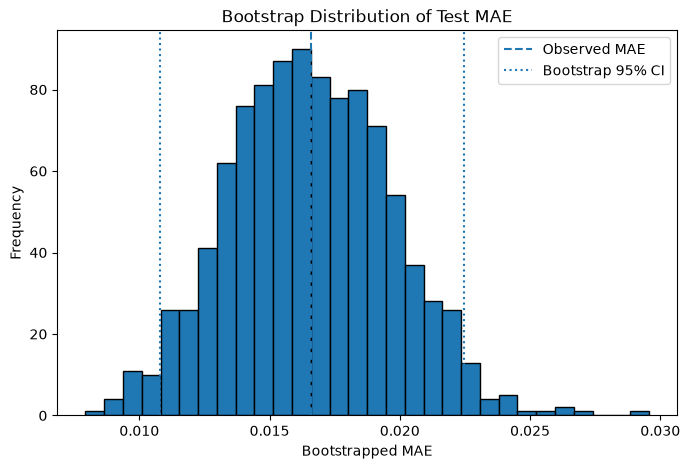

In [6]:
plt.hist(
    boot_mae,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    baseline_mae,
    linestyle="--",
    label="Observed MAE"
)

plt.axvline(
    boot_lower,
    linestyle=":",
    label="Bootstrap 95% CI"
)

plt.axvline(
    boot_upper,
    linestyle=":"
)

plt.xlabel("Bootstrapped MAE")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of Test MAE")
plt.legend()

plt.show()

## Scenario Sensitivity (Required): Choose ≥2 Scenarios
Examples: mean vs median impute; drop; alternate feature transform

In [7]:
model_df["lag_excess_sq"] = (
    model_df["lag_excess"] ** 2
)

cut = int(len(model_df) * 0.8)

train = model_df.iloc[:cut].copy()
test = model_df.iloc[cut:].copy()

scenario_features = {
    "Lag Only": [
        "lag_excess"
    ],

    "Lag + Volatility": [
        "lag_excess",
        "spy_vol_3"
    ],

    "Lag + Volatility + Squared Lag": [
        "lag_excess",
        "spy_vol_3",
        "lag_excess_sq"
    ]
}

scenario_results = []
scenario_predictions = {}

for name, feats in scenario_features.items():

    m = LinearRegression()

    m.fit(
        train[feats],
        train["target_next_excess"]
    )

    pred = m.predict(test[feats])

    scenario_predictions[name] = pred

    scenario_results.append({
        "Scenario": name,

        "MAE": mean_absolute_error(
            test["target_next_excess"],
            pred
        ),

        "R2": r2_score(
            test["target_next_excess"],
            pred
        )
    })

scenario_df = pd.DataFrame(scenario_results)

scenario_df

,Scenario,MAE,R2
0,Lag Only,0.016755,-0.170905
1,Lag + Volatility,0.016587,-0.187633
2,Lag + Volatility + Squared Lag,0.016047,-0.126262


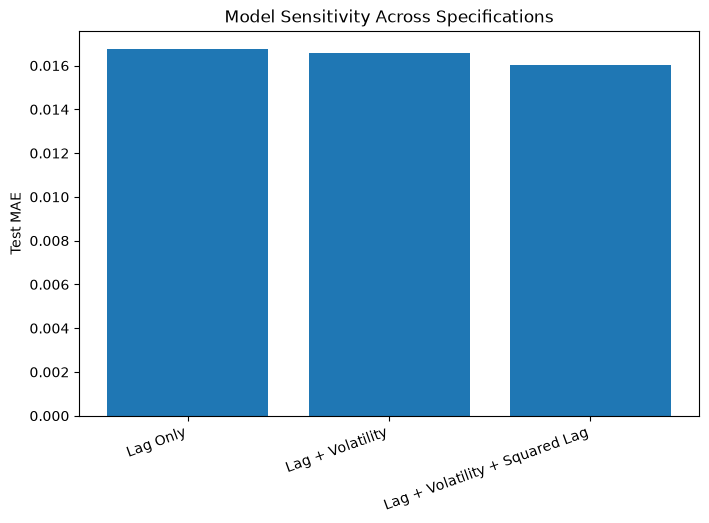

In [8]:
plt.figure()

plt.bar(
    scenario_df["Scenario"],
    scenario_df["MAE"]
)

plt.ylabel("Test MAE")
plt.title("Model Sensitivity Across Specifications")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.show()

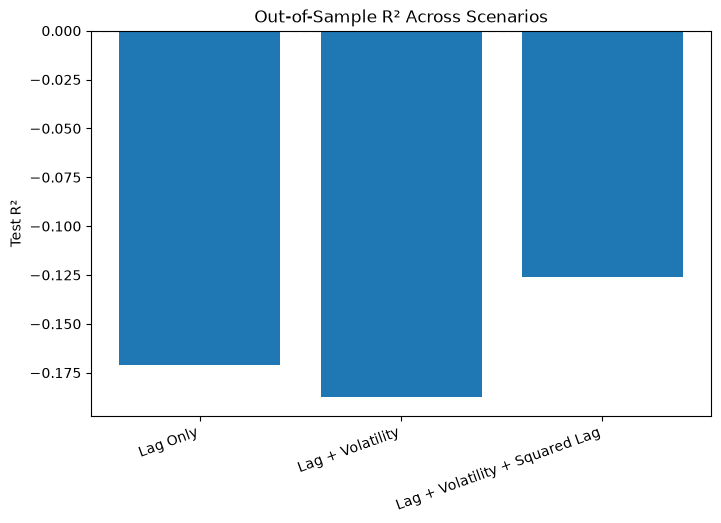

In [9]:
plt.figure()

plt.bar(
    scenario_df["Scenario"],
    scenario_df["R2"]
)

plt.axhline(0, linestyle="--")

plt.ylabel("Test R²")
plt.title("Out-of-Sample R² Across Scenarios")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.show()

## Subgroup Diagnostic (Required)

In [10]:
# Baseline predictions for subgroup analysis
baseline_model = LinearRegression()

baseline_model.fit(
    train[["lag_excess", "spy_vol_3"]],
    train["target_next_excess"]
)

test["prediction"] = baseline_model.predict(
    test[["lag_excess", "spy_vol_3"]]
)

test["residual"] = (
    test["target_next_excess"]
    - test["prediction"]
)

test["abs_error"] = np.abs(
    test["residual"]
)

subgroup_results = (
    test
    .groupby("market_regime")
    .agg(
        mean_residual=("residual", "mean"),
        median_residual=("residual", "median"),
        MAE=("abs_error", "mean"),
        count=("residual", "count")
    )
)

subgroup_results

,mean_residual,median_residual,MAE,count
market_regime,,,,
Down Market,0.015543,0.018966,0.023315,6
Up Market,-0.005534,-0.003035,0.013896,15


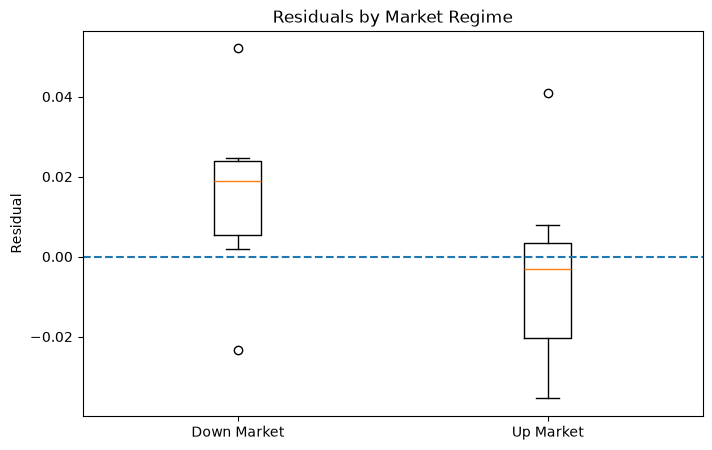

In [11]:
plt.figure()

grouped = test.groupby(
    "market_regime"
)["residual"]

data = [
    s.values
    for _, s in grouped
]

labels = list(
    grouped.groups.keys()
)

plt.boxplot(data)

plt.xticks(
    range(1, len(labels) + 1),
    labels
)

plt.axhline(
    0,
    linestyle="--"
)

plt.ylabel("Residual")
plt.title("Residuals by Market Regime")

plt.show()

## Bootstrap a Metric (Required)

In [12]:
bootstrap_summary = pd.Series({
    "Observed MAE": baseline_mae,
    "Bootstrap Mean MAE": boot_mae.mean(),
    "Bootstrap CI Lower": boot_lower,
    "Bootstrap CI Upper": boot_upper
})

bootstrap_summary

Observed MAE          0.016587
Bootstrap Mean MAE    0.016548
Bootstrap CI Lower    0.010793
Bootstrap CI Upper    0.022478
dtype: float64

## Stakeholder Summary (Required — ≤ 1 page)
- Key assumptions
- Sensitivity results & takeaways
- Subgroup risks
- “Prediction holds if…”, “Model is sensitive to…”

## Stakeholder Summary

The model uses recent momentum performance and recent S&P 500 volatility to estimate next-month momentum excess returns.

The model should not be treated as providing an exact forecast. Bootstrap analysis shows that the estimated prediction error itself is uncertain. The prediction is most credible if future market behavior remains reasonably similar to the historical sample used here.

I compared Gaussian-based and bootstrap-based uncertainty estimates to determine whether the reported uncertainty depends strongly on distributional assumptions.

I also tested several model specifications: lagged momentum alone, lagged momentum plus market volatility, and a specification that also includes squared lagged momentum. This sensitivity analysis shows whether the overall conclusion depends heavily on one modeling choice.

Finally, I evaluated prediction errors separately during up-market and down-market periods. Differences across these groups would suggest that the model is less reliable in certain market regimes.

Overall, I would use the model as a risk indicator rather than as an automatic trading or allocation rule. The model is sensitive to market regime, model specification, and the limited historical sample available.*Write your summary here…*